<a href="https://colab.research.google.com/github/Shah4l/deep-learning-projects/blob/main/CNN_1_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout,Conv2D,MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

In [ ]:
print("train image",x_train.shape)
print("test image",x_test.shape)

train image (60000, 28, 28)
test image (10000, 28, 28)


In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
x_train=x_train.reshape((x_train.shape[0],x_train.shape[1],x_train.shape[2],1))
x_test=x_test.reshape((x_test.shape[0],x_test.shape[1],x_test.shape[2],1))

In [ ]:
classes={0:'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',5:'Sandal',6:'Shirt',7:'Sneaker',8:'Bag',9:'Ankle boot'}

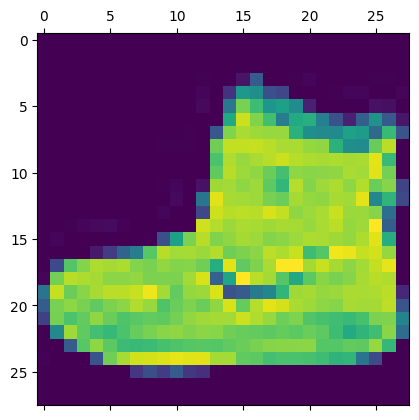

In [ ]:
plt.matshow(x_train[0])

In [ ]:
y_train[0]

np.uint8(9)

In [ ]:
classes[y_train[0]]

'Ankle boot'

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
x_test.shape

(10000, 28, 28, 1)

In [ ]:
model=Sequential()
model.add(Conv2D(32,(3,3),input_shape=(28,28,1),strides=(2,2),padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss=sparse_categorical_crossentropy,optimizer=Adam(),metrics=['accuracy'])

In [ ]:
trained_history=model.fit(x_train,y_train,batch_size=128,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.4411 - loss: 3.2104 - val_accuracy: 0.7874 - val_loss: 0.5686
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7724 - loss: 0.6056 - val_accuracy: 0.8279 - val_loss: 0.4697
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8075 - loss: 0.5174 - val_accuracy: 0.8415 - val_loss: 0.4361
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8297 - loss: 0.4566 - val_accuracy: 0.8557 - val_loss: 0.3971
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8395 - loss: 0.4363 - val_accuracy: 0.8636 - val_loss: 0.3829
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8480 - loss: 0.4130 - val_accuracy: 0.8689 - val_loss: 0.3670
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8561 - loss: 0.3861 - val_accuracy: 0.8742 - val_loss: 0.3504
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8623 - loss: 0.3768 - val_

In [ ]:
hist=trained_history.history
hist.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

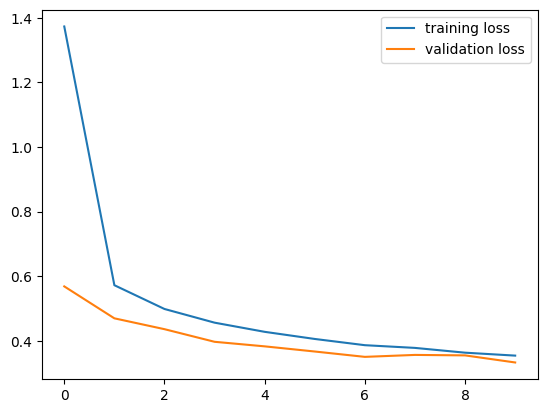

In [ ]:
plt.plot(hist['loss'],label="training loss")
plt.plot(hist['val_loss'],label="validation loss")
plt.legend()
plt.show()

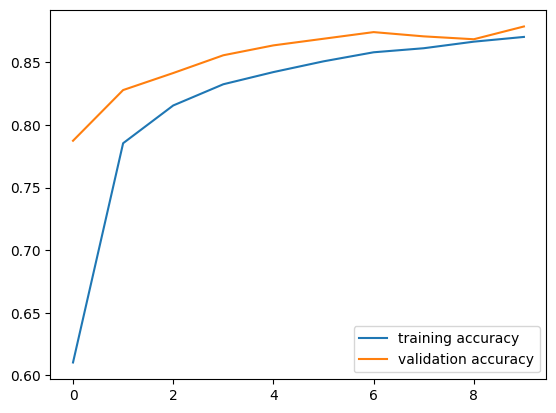

In [ ]:
plt.plot(hist['accuracy'],label="training accuracy")
plt.plot(hist['val_accuracy'],label="validation accuracy")
plt.legend()
plt.show()

In [ ]:
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[6.83939049e-07, 6.51626877e-08, 4.79983385e-07, ...,
        8.68786220e-03, 7.13595546e-06, 9.90714848e-01],
       [4.51585111e-05, 2.24254615e-09, 9.97762501e-01, ...,
        9.92565665e-12, 2.73554701e-06, 8.06421652e-10],
       [1.00461315e-11, 9.99999940e-01, 2.47959866e-14, ...,
        3.70817908e-19, 5.94794125e-14, 1.17798672e-15],
       ...,
       [2.95959380e-05, 1.07192243e-07, 1.35217829e-06, ...,
        2.24728822e-07, 9.99945819e-01, 1.21948730e-07],
       [2.37633385e-10, 9.99999702e-01, 1.81260059e-11, ...,
        4.38948719e-17, 6.44554592e-12, 8.27771503e-15],
       [5.17183775e-03, 1.40804434e-04, 1.80966570e-03, ...,
        3.02756429e-01, 2.45883018e-02, 1.83784515e-02]], dtype=float32)

In [ ]:
import numpy as np
def predict(index):
  plt.imshow(x_test[index])
  pred_image=x_test[index].reshape(1,28,28,1)
  pred_prob=model.predict(pred_image)
  pred_class=np.argmax(pred_prob)
  print('Original class:',classes[y_test[index]])
  print('Predicted class:',classes[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Original class: T-shirt/top
Predicted class: T-shirt/top


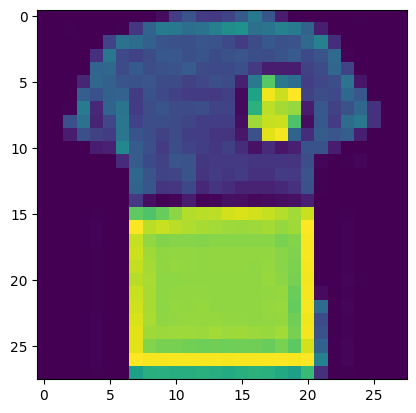

In [ ]:
predict(120)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Original class: T-shirt/top
Predicted class: T-shirt/top


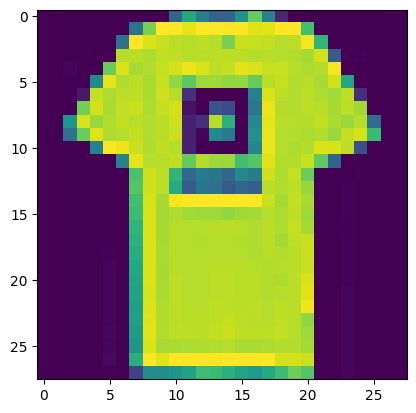

In [ ]:
predict(121)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Original class: Ankle boot
Predicted class: Ankle boot


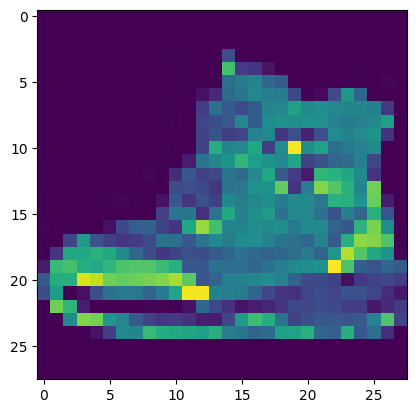

In [ ]:
predict(122)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Original class: Ankle boot
Predicted class: Ankle boot


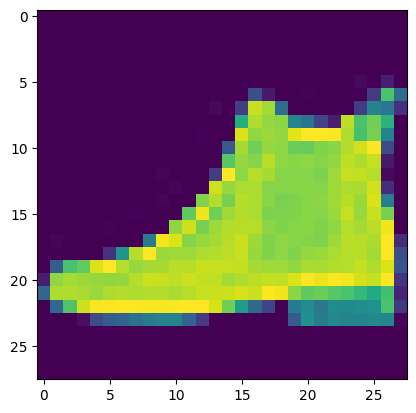

In [ ]:
predict(123)